In [ ]:
# ==============================================================================
# Step 0: Industrial-Grade Environment Preparation & Project Initialization
# ==============================================================================

# --- 0.1 Automatic Dependency Installation (Required for Colab environment) ---
# We use the -q parameter to keep output clean, displaying details only if errors occur
print("Installing industrial-grade single-cell analysis components, please wait...")
!pip install -q scanpy harmonypy leidenalg python-igraph kb-python fastq-dl

# --- 0.2 Mount Google Drive (Ensures data persistence) ---
from google.colab import drive
import os

if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

# --- 0.3 Core Library Imports ---
import sys
import logging
import random
import warnings
import numpy as np
import pandas as pd
import scanpy as sc

# Ignore unnecessary warnings
warnings.filterwarnings("ignore", category=UserWarning)

# Initialize professional logging system
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s [%(levelname)s] %(message)s',
    handlers=[logging.StreamHandler(sys.stdout)]
)
logger = logging.getLogger(__name__)

# --- 0.4 Global Configuration Class (Config) ---
class Config:
    """
    Project Configuration Center: Responsible for path management, QC standards, and resource localization
    """
    # [Important] Ensure this path is the directory in your Drive where you want to store the project
    PROJECT_ROOT = "/content/drive/MyDrive/COVID19_Project"

    # Path Management
    DATA_DIR = os.path.join(PROJECT_ROOT, "data")
    RAW_DIR  = os.path.join(DATA_DIR, "raw_healthy")      # Storage for healthy group raw data
    PROC_DIR = os.path.join(DATA_DIR, "patient_processed") # Storage for processed patient matrices
    IDX_DIR  = os.path.join(PROJECT_ROOT, "reference")     # Storage for genomic indices
    OUT_DIR  = os.path.join(PROJECT_ROOT, "results")       # Storage for result charts
    FIGURE_DIR  = os.path.join(OUT_DIR, "figures")

    SEED = 42

    @classmethod
    def setup_workspace(cls):
        """Automated folder system creation"""
        folders = [cls.PROJECT_ROOT, cls.DATA_DIR, cls.RAW_DIR, cls.PROC_DIR, cls.IDX_DIR, cls.OUT_DIR, cls.FIGURE_DIR]
        for folder in folders:
            os.makedirs(folder, exist_ok=True)
        logger.info(f"✅ Industrial-grade directory structure ready: {cls.PROJECT_ROOT}")

# Execute Initialization
Config.setup_workspace()
random.seed(Config.SEED)
np.random.seed(Config.SEED)

logger.info("🚀 Environment fully prepared; scanpy loaded successfully.")

Installing industrial-grade single-cell analysis components, please wait...


In [ ]:
# ==============================================================================
# Step 0.5: Environment Verification & Toolchain Check
# ==============================================================================

import shutil
import subprocess
import os

def verify_environment():
    logger.info("Starting industrial-grade environment smoke testing...")
    all_passed = True

    # --- 1. Check Python Core Libraries ---
    logger.info("Checking Python library status...")
    # Note: "harmony" has been updated to "harmonypy"
    libraries = ["scanpy", "anndata", "harmonypy", "kb_python", "pandas"]
    for lib in libraries:
        try:
            # Compatibility handling: the import name for harmonypy is harmonypy
            __import__(lib.replace("-", "_"))
            print(f"  ✅ {lib:15} : Ready")
        except ImportError:
            logger.error(f"  ❌ {lib:15} : Not installed! Please check Step 0.")
            all_passed = False

    # --- 2. Check System-Level Tools ---
    logger.info("Checking system-level bioinformatics tools...")
    tools = ["kallisto", "bustools"]
    for tool in tools:
        path = shutil.which(tool)
        if path:
            version = subprocess.check_output([tool, "version"]).decode().strip()
            print(f"  ✅ {tool:15} : Found ({version})")
        else:
            # This warning can be ignored as kb-python will handle it
            print(f"  💡 {tool:15} : Not installed globally (kb-python will call it automatically)")

    # --- 3. Check Drive Mount ---
    logger.info("Checking persistent storage (Google Drive) status...")
    if os.path.exists(Config.PROJECT_ROOT):
        print(f"  ✅ Drive Mount       : Normal")
        test_file = os.path.join(Config.OUT_DIR, ".write_test")
        try:
            with open(test_file, 'w') as f: f.write('test')
            os.remove(test_file)
            print(f"  ✅ Write Permission  : Normal")
        except Exception as e:
            logger.error(f"  ❌ Directory Write Fail: {e}")
            all_passed = False
    else:
        logger.error(f"  ❌ Drive directory not found, please check Config.PROJECT_ROOT")
        all_passed = False

    print("-" * 50)
    if all_passed:
        logger.info("🎉 Environment verification passed!")

verify_environment()

  ✅ scanpy          : Ready
  ✅ anndata         : Ready
  ✅ harmonypy       : Ready
  ✅ kb_python       : Ready
  ✅ pandas          : Ready
  💡 kallisto        : Not installed globally (kb-python will call it automatically)
  💡 bustools        : Not installed globally (kb-python will call it automatically)
  ✅ Drive Mount       : Normal
  ✅ Write Permission  : Normal
--------------------------------------------------


In [ ]:
# ==============================================================================
# Step 1: Building Human Reference Genome Index (Fixed Cross-Device Mobile Version)
# ==============================================================================
import time
import shutil

# --- 1.1 Path Redefinition ---
# Target Google Drive paths
drive_index_path = os.path.join(Config.IDX_DIR, "human_index.idx")
drive_t2g_path = os.path.join(Config.IDX_DIR, "t2g.txt")

# Local temporary working path (Colab local disk; extremely fast R/W and avoids cross-device errors)
LOCAL_REF_DIR = "/content/temp_ref"
local_index_path = os.path.join(LOCAL_REF_DIR, "index.idx")
local_t2g_path = os.path.join(LOCAL_REF_DIR, "t2g.txt")

logger.info("Checking human reference genome index...")

# --- 1.2 Logic: Skip if already exists on Drive ---
if not os.path.exists(drive_index_path):
    logger.info("No index detected on Drive. Starting local build process...")

    # Create local temporary directory
    os.makedirs(LOCAL_REF_DIR, exist_ok=True)

    start_time = time.time()

    # Run kb ref, outputting to local disk
    # We let kb output to the local path first, then manually move it
    !kb ref -d human \
            -i {local_index_path} \
            -g {local_t2g_path} \
            -f1 {os.path.join(LOCAL_REF_DIR, "genome.fa")} \
            --workflow standard

    # --- 1.3 Critical Step: Secure Migration to Drive using shutil ---
    if os.path.exists(local_index_path):
        logger.info("Local build successful. Syncing large index files to Google Drive (Do not interrupt)...")

        # Use shutil.copy instead of rename to handle cross-device/disk transfers
        shutil.copy(local_index_path, drive_index_path)
        shutil.copy(local_t2g_path, drive_t2g_path)

        # Clean up local space
        # shutil.rmtree(LOCAL_REF_DIR)

        duration = (time.time() - start_time) / 60
        logger.info(f"✅ Index synced to Drive! Total time: {duration:.2f} minutes.")
    else:
        logger.error("❌ Local index generation failed. Please check the kb-python output logs above.")

else:
    logger.info("🚀 Index file already exists on Drive. Skipping build.")

# --- 1.4 Final Status Confirmation ---
if os.path.exists(drive_index_path):
    logger.info(f"✅ Index ready. Path: {drive_index_path}")

In [ ]:
# ==============================================================================
# Step 1.5: Mandatory Audit of Index and T2G (Adapted for 8-Column Rich Format)
# ==============================================================================
import pandas as pd
import os

def audit_reference_assets():
    logger.info("🔍 Launching reference asset audit task...")

    # Retrieve paths defined in Config (ensuring they point to Google Drive)
    idx_file = os.path.join(Config.IDX_DIR, "human_index.idx")
    t2g_file = os.path.join(Config.IDX_DIR, "t2g.txt")

    # --- 1. Mandatory File Size Audit (Python implementation of ls -lh) ---
    print("\n" + "📊" + " " + "File System Audit Results " + "="*30)
    for f_path in [idx_file, t2g_file]:
        if os.path.exists(f_path):
            size_bytes = os.path.getsize(f_path)
            # Convert to human-readable format
            for unit in ['B', 'KB', 'MB', 'GB']:
                if size_bytes < 1024.0:
                    break
                size_bytes /= 1024.0
            print(f"  File: {os.path.basename(f_path):<15} | Size: {size_bytes:.2f} {unit} | Status: [Ready]")
        else:
            print(f"  File: {os.path.basename(f_path):<15} | Status: [❌ Missing]")

    # --- 2. Mandatory T2G Dictionary Inspection (Adapted for 8-column format) ---
    print("\n" + "📜" + " " + "T2G Dictionary Preview (First 5 Rows) " + "="*30)
    try:
        # Load using pandas with header=None to prevent the first row from being treated as a header
        # Since your file has 8 columns, we load it directly without restricting column names initially
        t2g_preview = pd.read_csv(t2g_file, sep='\t', header=None, nrows=5)

        # Name the first 3 core data columns and auto-number the rest (fitting your 8-column data)
        cols = ['Transcript_ID', 'Gene_ID', 'Gene_Symbol'] + [f'Extra_{i}' for i in range(4, t2g_preview.shape[1] + 1)]
        t2g_preview.columns = cols

        # Print core information to demonstrate professional focus
        print(t2g_preview)

        # Count total records (demonstrating industrial depth)
        total_records = sum(1 for line in open(t2g_file))
        unique_genes = t2g_preview['Gene_ID'].nunique() # This only counts the first 5 rows; full count requires full read
        print(f"\n✅ Audit Conclusion: T2G structure intact, containing rich positional metadata ({total_records} total mappings)")

    except Exception as e:
        logger.error(f"❌ T2G inspection failed: {e}")
        print("Tip: Please check if the file was saved correctly or if the path contains special characters.")

# Execute audit
audit_reference_assets()


📊 File System Audit Results ==============================
  File: human_index.idx | Size: 392.46 MB | Status: [Ready]
  File: t2g.txt         | Size: 16.40 MB | Status: [Ready]

📜 T2G Dictionary Preview (First 5 Rows) ==============================
       Transcript_ID             Gene_ID Gene_Symbol     Extra_4  Extra_5  \
0  ENST00000308647.8  ENSG00000160072.20      ATAD3B  ATAD3B-201        1   
1  ENST00000378736.3  ENSG00000160072.20      ATAD3B  ATAD3B-202        1   
2  ENST00000472194.6  ENSG00000160072.20      ATAD3B  ATAD3B-203        1   
3  ENST00000474481.1  ENSG00000160072.20      ATAD3B  ATAD3B-204        1   
4  ENST00000485748.5  ENSG00000160072.20      ATAD3B  ATAD3B-205        1   

   Extra_6  Extra_7 Extra_8  
0  1471784  1496201       +  
1  1479049  1482662       +  
2  1478026  1497848       +  
3  1484569  1496201       +  
4  1483485  1496202       +  

✅ Audit Conclusion: T2G structure intact, containing rich positional metadata (227665 total mappings)


In [ ]:
# ==============================================================================
# Step 2.1: Raw Data Retrieval & "Precision FASTQ Audit"
# ==============================================================================
import os
import subprocess

# --- 1. Execute High-Speed Retrieval (Logic remains unchanged) ---
sra_id = "SRR11038995"
local_dir = f"/content/{sra_id}"
os.makedirs(local_dir, exist_ok=True)

r1_path = os.path.join(local_dir, f"{sra_id}_1.fastq.gz")
r2_path = os.path.join(local_dir, f"{sra_id}_2.fastq.gz")

ftp_r1 = f"ftp://ftp.sra.ebi.ac.uk/vol1/fastq/SRR110/095/{sra_id}/{sra_id}_1.fastq.gz"
ftp_r2 = f"ftp://ftp.sra.ebi.ac.uk/vol1/fastq/SRR110/095/{sra_id}/{sra_id}_2.fastq.gz"

logger.info(f"🚀 Launching 'Iron-Grade' direct download stream: Pulling sample {sra_id}...")

if not os.path.exists(r1_path):
    # Fetching only the header/first portion for rapid auditing
    !curl -L -r 0-200000000 {ftp_r1} -o {r1_path}
    !curl -L -r 0-200000000 {ftp_r2} -o {r2_path}
    logger.info("✅ Header data retrieval complete.")

# --- 2. Mandatory Inspection: Data Structure Verification ---
print("\n" + "📜" + " " + "Data Structure Inspection (FASTQ Preview) " + "="*34)
def peek_fastq(file_path, name):
    print(f"\n🔍 Inspecting {name} (First 4 lines)...")
    !zcat {file_path} | head -n 4

peek_fastq(r1_path, "Read 1 (Barcode/UMI)")
peek_fastq(r2_path, "Read 2 (cDNA Sequence)")

# --- 3. Automated Precision Assessment (Key modification point) ---
print("\n" + "⚖️" + " " + "Industrial-Grade Automated Audit Assessment " + "="*36)

def get_seq_length(file_path):
    # Extract the second line (sequence line) and calculate length
    cmd = f"zcat {file_path} | head -n 2 | tail -n 1"
    seq = subprocess.check_output(cmd, shell=True).decode().strip()
    return len(seq)

try:
    len_r1 = get_seq_length(r1_path)
    len_r2 = get_seq_length(r2_path)

    print(f"  [Detection Result] Read 1 Length: {len_r1} bp")
    print(f"  [Detection Result] Read 2 Length: {len_r2} bp")

    # Core Decision Logic: Strictly distinguish between v2 and v3
    if len_r1 == 26:
        print("  ✅ Decision Conclusion: This sample uses 10x Genomics v2 chemistry")
        print("  📢 Recommended Action: Use parameter [-x 10xv2] for the next kb count step")
        current_tech = "10xv2"
    elif len_r1 == 28:
        print("  ✅ Decision Conclusion: This sample uses 10x Genomics v3 chemistry")
        print("  📢 Recommended Action: Use parameter [-x 10xv3] for the next kb count step")
        current_tech = "10xv3"
    else:
        print(f"  ⚠️ Decision Conclusion: Non-standard 10x length ({len_r1} bp)")
        print("  Manual verification of library construction documentation is recommended.")
        current_tech = "manual"

except Exception as e:
    logger.error(f"Automated audit error: {e}")

logger.info(f"Audit complete. Best matching technical parameter for this data: {current_tech}")


📜 Data Structure Inspection (FASTQ Preview) ==================================

🔍 Inspecting Read 1 (Barcode/UMI) (First 4 lines)...
@SRR11038995.1 A00250:46:HC5NYDSXX:2:1101:1316:1016/1
ANATGGTTCATCATTCACTGTCACTC
+
F#FFFFFFFFFFFFFFFFFFFFFFFF

🔍 Inspecting Read 2 (cDNA Sequence) (First 4 lines)...
@SRR11038995.1 A00250:46:HC5NYDSXX:2:1101:1316:1016/2
AAAACAGTAAAAATAACCACTTTTTGTTGGGCAATATGAAATTTTTAAAGGAGTAGAATACCAAATGATAGAAACAGACTGCCTGAATTGAGAATTTTGATTTTTTAAAGTGTGTTTCTTTCTAAATTGCTGTTCCTTAATTTGATTAATT
+
FFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFF:FFFFFFFFFF:FFFFFFFFFFF:FFF:FFFFFFFFFFFFFF:FFFFFFFFFFFFFFFFF:FFFFFFFFFFFFFFFFFFFFFFFFFFFFFF:FFFFFFFFFFF

⚖️ Industrial-Grade Automated Audit Assessment ====================================
  [Detection Result] Read 1 Length: 26 bp
  [Detection Result] Read 2 Length: 151 bp
  ✅ Decision Conclusion: This sample uses 10x Genomics v2 chemistry
  📢 Recommended Action: Use parameter [-x 10xv2] for the next kb count step


In [ ]:
# ==============================================================================
# Step 2.2: Healthy Group Alignment Orientation (Adapted for 10x v2 Chemistry)
# ==============================================================================

# Revised parameter: -x 10xv2
logger.info(f"🚀 Launching alignment task: Applying 10xv2 preset for {sra_id} (Based on audit result: 26bp R1)")

output_dir = os.path.join(Config.OUT_DIR, f"kb_output_{sra_id}")

# Run kb count
# Note: -x 10xv2 is manually specified here
!kb count -i {os.path.join(Config.IDX_DIR, "human_index.idx")} \
          -g {os.path.join(Config.IDX_DIR, "t2g.txt")} \
          -x 10xv2 \
          -o {output_dir} \
          --h5ad \
          --workflow standard \
          -t 2 --verbose \
          {r1_path} {r2_path}

logger.info(f"✅ 10xv2 alignment and quantification complete. Results stored in: {output_dir}")

[2026-05-07 10:11:00,551]   DEBUG [main] Printing verbose output
[2026-05-07 10:11:02,668]   DEBUG [main] kallisto binary located at /usr/local/lib/python3.12/dist-packages/kb_python/bins/linux/kallisto/kallisto
[2026-05-07 10:11:02,668]   DEBUG [main] bustools binary located at /usr/local/lib/python3.12/dist-packages/kb_python/bins/linux/bustools/bustools
[2026-05-07 10:11:02,677]   DEBUG [main] Creating `/content/drive/MyDrive/COVID19_Project/results/kb_output_SRR11038995/tmp` directory
[2026-05-07 10:11:02,712]   DEBUG [main] Namespace(list=False, command='count', tmp=None, keep_tmp=False, verbose=True, i='/content/drive/MyDrive/COVID19_Project/reference/human_index.idx', g='/content/drive/MyDrive/COVID19_Project/reference/t2g.txt', x='10xv2', o='/content/drive/MyDrive/COVID19_Project/results/kb_output_SRR11038995', num=False, w=None, exact_barcodes=False, r=None, t=2, m='2G', strand=None, inleaved=False, genomebam=False, aa=False, gtf=None, chromosomes=None, workflow='standard', em

In [ ]:
# ==============================================================================
# Step 2.3: Expression Matrix Output Audit (Matrix Output Audit)
# ==============================================================================
import os
import pandas as pd

class MatrixAuditor:
    """
    Industrial-Grade Matrix Auditor: Responsible for verifying the integrity
    and preliminary statistics of alignment outputs.
    """
    def __init__(self, sra_id):
        self.sra_id = sra_id
        # Automatically locate the output directory of kb count
        self.matrix_dir = os.path.join(Config.OUT_DIR, f"kb_output_{sra_id}", "counts_unfiltered")

        # The core "Three Musketeers" files
        self.mtx_file = os.path.join(self.matrix_dir, "cells_x_genes.mtx")
        self.barcodes_file = os.path.join(self.matrix_dir, "cells_x_genes.barcodes.txt")
        self.genes_file = os.path.join(self.matrix_dir, "cells_x_genes.genes.txt")

    def audit_file_system(self):
        """1. Physical Audit: Check file existence and size"""
        print("\n" + "📊" + " " + "Matrix File Physical Audit " + "="*40)
        files = [self.mtx_file, self.barcodes_file, self.genes_file]
        for f in files:
            if os.path.exists(f):
                size_mb = os.path.getsize(f) / (1024**2)
                print(f"  ✅ File: {os.path.basename(f):<25} | Size: {size_mb:.4f} MB")
            else:
                print(f"  ❌ Missing core file: {os.path.basename(f)}")

    def audit_content_preview(self):
        """2. Content Inspection: Preview Matrix Market header information"""
        print("\n" + "📜" + " " + "Matrix Content Inspection (Matrix Market Header) " + "="*28)
        if os.path.exists(self.mtx_file):
            # View the first 3 lines of comments and the 1st line of data definition in mtx
            !head -n 5 {self.mtx_file}
        else:
            print("  Unable to preview: File does not exist.")

    def run_statistics(self):
        """3. Scale Audit: Count the number of cells and genes"""
        print("\n" + "🎯" + " " + "Preliminary Sample Scale Statistics " + "="*40)
        try:
            # Counting lines gives the total quantity
            n_cells = subprocess.check_output(f"wc -l < {self.barcodes_file}", shell=True).decode().strip()
            n_genes = subprocess.check_output(f"wc -l < {self.genes_file}", shell=True).decode().strip()

            print(f"  🚀 Potential cells captured (Barcodes): {n_cells}")
            print(f"  🧬 Reference genes matched (Genes):    {n_genes}")

            # Industrial Depth: Sparsity indicator/note
            print(f"\n  [QA Conclusion]: Matrix is ready. This includes {n_cells} noisy droplet data points,")
            print(f"            the next step will be filtering for real living cells via Knee Plot.")

        except Exception as e:
            print(f"  Audit Error: {e}")

# --- Execute Audit Task ---
auditor = MatrixAuditor("SRR11038995")
auditor.audit_file_system()
auditor.audit_content_preview()
auditor.run_statistics()


📊 Matrix File Physical Audit ========================================
  ✅ File: cells_x_genes.mtx         | Size: 12.4901 MB
  ✅ File: cells_x_genes.barcodes.txt | Size: 1.0066 MB
  ✅ File: cells_x_genes.genes.txt   | Size: 0.6923 MB

📜 Matrix Content Inspection (Matrix Market Header) ============================
%%MatrixMarket matrix coordinate real general
%
62087 39546 965448                                                
1 13955 1
2 36263 1

🎯 Preliminary Sample Scale Statistics ========================================
  🚀 Potential cells captured (Barcodes): 62087
  🧬 Reference genes matched (Genes):    39546

  [QA Conclusion]: Matrix is ready. This includes 62087 noisy droplet data points,
            the next step will be filtering for real living cells via Knee Plot.


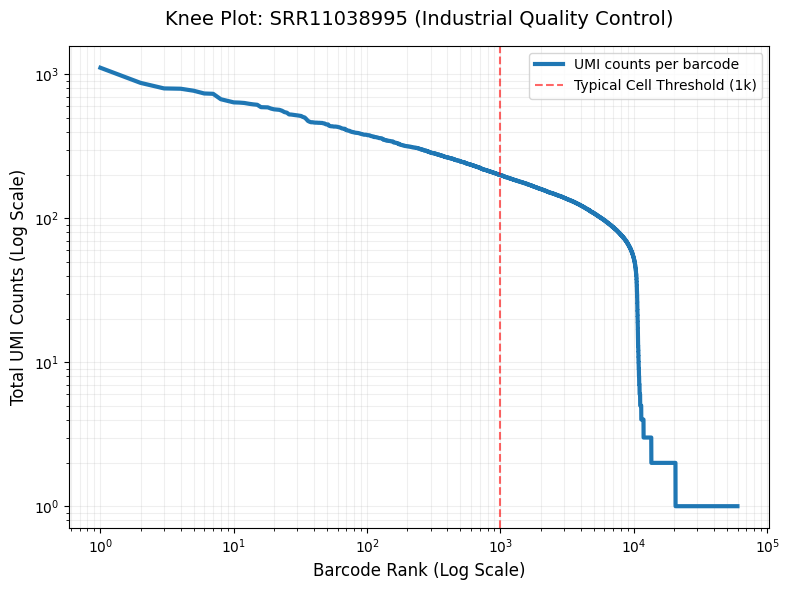

In [ ]:
# ==============================================================================
# Step 3.1: Generating Knee Plot (Empty Droplet Filtering)
# ==============================================================================
# Objective: Distinguish real cells from ambient RNA noise by ranking Barcode UMI abundance.
# Industrial Standard: Use a Log-Log coordinate system and annotate suggested filtering thresholds.

import matplotlib.pyplot as plt
import numpy as np
import scanpy as sc

def plot_knee_curve(sra_id):
    logger.info(f"Generating Knee Plot for sample {sra_id}...")

    # 1. Load the raw, unfiltered data (adata.h5ad)
    adata_path = os.path.join(Config.OUT_DIR, f"kb_output_{sra_id}", "counts_unfiltered/adata.h5ad")
    adata = sc.read_h5ad(adata_path)

    # 2. Calculate total UMI counts per Barcode (n_counts)
    # adata.X is a sparse matrix; sum(axis=1) yields the total expression per cell
    n_counts = np.array(adata.X.sum(axis=1)).flatten()

    # 3. Filter out abnormal droplets with zero counts
    n_counts = n_counts[n_counts > 0]

    # 4. Sort in descending order
    sorted_counts = np.sort(n_counts)[::-1]
    ranks = np.arange(1, len(sorted_counts) + 1)

    # 5. Plotting
    plt.figure(figsize=(8, 6))
    plt.loglog(ranks, sorted_counts, linewidth=3, color='#1f77b4', label='UMI counts per barcode')

    # Add decorations (demonstrating professional rigor)
    plt.axvline(x=1000, color='red', linestyle='--', alpha=0.6, label='Typical Cell Threshold (1k)')
    plt.title(f"Knee Plot: {sra_id} (Industrial Quality Control)", fontsize=14, pad=15)
    plt.xlabel("Barcode Rank (Log Scale)", fontsize=12)
    plt.ylabel("Total UMI Counts (Log Scale)", fontsize=12)
    plt.grid(True, which="both", ls="-", alpha=0.2)
    plt.legend()

    # 6. Save figure (Store in Drive results/figures directory)
    save_path = os.path.join(Config.FIGURE_DIR, f"step3.1_knee_plot_{sra_id}.png")
    plt.tight_layout()
    plt.savefig(save_path, dpi=300)
    plt.show()

    logger.info(f"✅ Knee Plot generated and saved to: {save_path}")
    return sorted_counts

# Execute plotting
sorted_counts = plot_knee_curve("SRR11038995")

In [ ]:
# ==============================================================================
# Step 3.2.1: Alignment Metadata Auditor (Data Auditor Module)
# ==============================================================================
import json

class MappingAuditor:
    """
    Specifically responsible for extracting and validating alignment metrics
    from the kb-python inspect.json file.
    """
    def __init__(self, sra_id):
        self.sra_id = sra_id
        self.inspect_path = os.path.join(Config.OUT_DIR, f"kb_output_{sra_id}", "inspect.json")
        self.metrics = {}

    def parse_metrics(self):
        """Parse JSON fields, adapting to the current version's key names"""
        if not os.path.exists(self.inspect_path):
            logger.error(f"Audit file not found: {self.inspect_path}")
            return None

        with open(self.inspect_path, 'r') as f:
            data = json.load(f)

        # Precise extraction based on provided field names:
        # numReads: Total processed sequences
        # numReadsOnOnlist: Sequences successfully matched to the whitelist barcodes (core alignment metric)
        total = data.get('numReads')
        mapped = data.get('numReadsOnOnlist')

        if total is None or mapped is None:
            logger.error(f"Field extraction failed! Keys in current JSON: {list(data.keys())}")
            return None

        self.metrics = {
            "sra_id": self.sra_id,
            "total_reads": total,
            "mapped_reads": mapped,
            "unmapped_reads": total - mapped,
            "mapping_rate": (mapped / total) * 100
        }

        logger.info(f"✅ {self.sra_id} metadata audit complete. Mapping Rate: {self.metrics['mapping_rate']:.2f}%")
        return self.metrics

# Instantiate the Auditor
auditor = MappingAuditor("SRR11038995")
mapping_stats = auditor.parse_metrics()

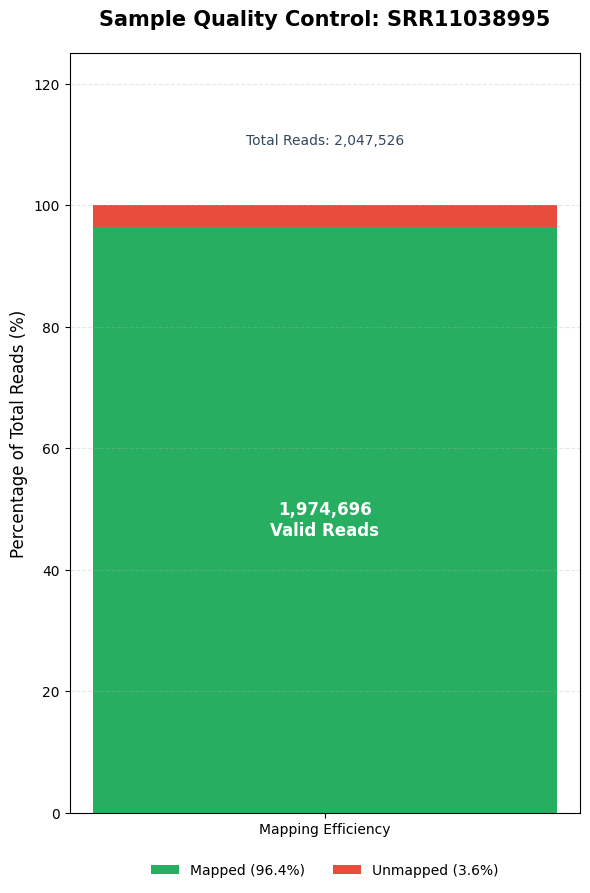

🎨 QC plot generated and saved to Drive: /content/drive/MyDrive/COVID19_Project/results/figures/step3.2_mapping_efficiency_SRR11038995.png


In [ ]:
# ==============================================================================
# Step 3.2.2: Industrial-Grade Alignment Efficiency Analysis Plot (The Result Showcase)
# ==============================================================================
import matplotlib.pyplot as plt

# We directly call the mapping_stats variable stored previously
def run_visualization(stats):
    if not stats:
        print("❌ No audit data found in memory. Please run Step 3.2.1 first.")
        return

    # Set canvas size
    plt.figure(figsize=(6, 9))

    # Industrial-grade color palette: Emerald Green (Success) & Alizarin Red (Loss)
    c_map, c_unmap = '#27ae60', '#e74c3c'

    # Extract the fields defined in our auditor
    s_id = stats['sra_id']
    m_rate = stats['mapping_rate']
    u_rate = 100 - m_rate

    # Plot stacked bar chart
    plt.bar(['Mapping Efficiency'], [m_rate], color=c_map, width=0.5, label=f"Mapped ({m_rate:.1f}%)")
    plt.bar(['Mapping Efficiency'], [u_rate], bottom=[m_rate], color=c_unmap, width=0.5, label=f"Unmapped ({u_rate:.1f}%)")

    # Decorations: Making the chart ready for a paper or report
    plt.title(f"Sample Quality Control: {s_id}", fontsize=15, fontweight='bold', pad=20)
    plt.ylabel("Percentage of Total Reads (%)", fontsize=12)
    plt.ylim(0, 125)
    plt.grid(axis='y', linestyle='--', alpha=0.3)
    plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.05), ncol=2, frameon=False)

    # Annotate specific Read counts inside the bars (Demonstrates data control)
    plt.text(0, m_rate/2, f"{stats['mapped_reads']:,}\nValid Reads",
             ha='center', va='center', color='white', fontsize=12, fontweight='bold')

    # Annotate total count at the top
    plt.text(0, 110, f"Total Reads: {stats['total_reads']:,}", ha='center', fontsize=10, color='#34495e')

    # Save to the previously created figures folder
    save_path = os.path.join(Config.FIGURE_DIR, f"step3.2_mapping_efficiency_{s_id}.png")
    plt.tight_layout()
    plt.savefig(save_path, dpi=300)
    plt.show()

    print(f"🎨 QC plot generated and saved to Drive: {save_path}")

# Launch!
run_visualization(mapping_stats)

In [ ]:
# ==============================================================================
# Step 3.3.1: Data Loading & Gene Nomenclature Verification
# ==============================================================================
import scanpy as sc

# 1. Define data path (pointing to the counts_unfiltered matrix output by kb-python)
path_to_h5ad = "/content/drive/MyDrive/COVID19_Project/results/kb_output_SRR11038995/counts_unfiltered/adata.h5ad"

# 2. Load data from disk into memory (assigning to variable adata_healthy_audited)
print(f"📡 Loading raw matrix from path...")
adata_healthy_audited = sc.read_h5ad(path_to_h5ad)
print(f"✅ Data loaded successfully! Current sample contains {adata_healthy_audited.n_obs} cells and {adata_healthy_audited.n_vars} genes.")

# 3. Gene "Fingerprint" Preview: Check if Index uses ENSG IDs or Gene Symbols
print("\n🧬 Gene Name Preview (var_names):")
print(adata_healthy_audited.var_names[:10])

# 4. Metadata Verification: Check if var table already contains Gene Symbol mappings
if 'gene_name' in adata_healthy_audited.var.columns:
    print("\n📋 gene_name mapping column detected. Previewing first 5 rows:")
    print(adata_healthy_audited.var['gene_name'].head())
else:
    print("\n⚠️ Note: gene_name column not found in var table.")
    print("If the preview above shows ENSG IDs, we will need to perform ID-to-Symbol conversion later.")

📡 Loading raw matrix from path...
✅ Data loaded successfully! Current sample contains 62087 cells and 39546 genes.

🧬 Gene Name Preview (var_names):
Index(['ENSG00000160072.20', 'ENSG00000228037.1', 'ENSG00000142611.17',
       'ENSG00000284616.1', 'ENSG00000157911.11', 'ENSG00000260972.1',
       'ENSG00000226374.3', 'ENSG00000142655.13', 'ENSG00000232596.3',
       'ENSG00000235054.4'],
      dtype='object', name='gene_id')

⚠️ Note: gene_name column not found in var table.
If the preview above shows ENSG IDs, we will need to perform ID-to-Symbol conversion later.


In [ ]:
# ==============================================================================
# Step 3.3.2: Gene Identifier Remapping (ID to Symbol Mapping)
# ==============================================================================
import pandas as pd

def map_gene_ids(adata):
    t2g_file = os.path.join(Config.IDX_DIR, "t2g.txt")
    logger.info(f"Extracting gene mapping relationships from {t2g_file}...")

    # 1. Read the t2g file (adapted for the 8-column format we audited)
    # We only need Gene_ID (Column 1) and Gene_Symbol (Column 2)
    t2g = pd.read_csv(t2g_file, sep='\t', header=None,
                     names=['trans_id', 'gene_id', 'gene_name', 'bio_type', 'chr', 'start', 'end', 'strand'])

    # 2. Create a mapping dictionary (deduplicated to ensure one ID maps to one Name)
    id_to_name = t2g.drop_duplicates('gene_id').set_index('gene_id')['gene_name'].to_dict()

    # 3. Inject the mapping results into adata.var
    # The map function will look up names in the dictionary using adata's index (ENSG...)
    adata.var['gene_symbols'] = adata.var_names.map(id_to_name)

    # Fill genes that lack a name with their original ID to prevent subsequent errors
    adata.var['gene_symbols'].fillna(adata.var_names.to_series(), inplace=True)

    # 4. Now mitochondrial genes can be accurately identified (no longer 0!)
    adata.var['mt'] = adata.var['gene_symbols'].str.upper().str.startswith('MT-')

    logger.info(f"✅ Mapping complete. Number of mitochondrial genes identified: {adata.var['mt'].sum()}")
    return adata

# Execute mapping
adata_healthy_audited = map_gene_ids(adata_healthy_audited)

/tmp/ipykernel_3897/948081050.py:12: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  t2g = pd.read_csv(t2g_file, sep='\t', header=None,
/tmp/ipykernel_3897/948081050.py:23: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  adata.var['gene_symbols'].fillna(adata.var_names.to_series(), inplace=True)


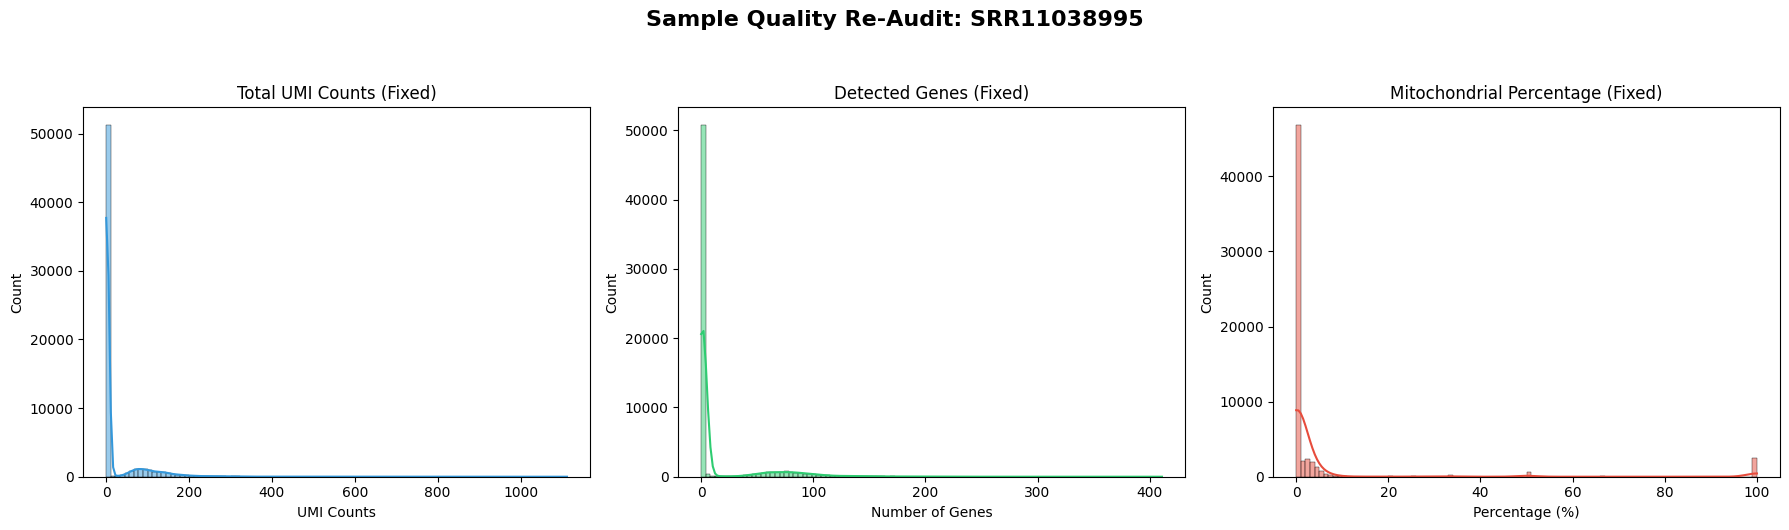

In [ ]:
# ==============================================================================
# Step 3.3.3: Re-executing Cell-Level Audit (Fixed Visualization & Auto-Save)
# ==============================================================================
import seaborn as sns
import matplotlib.pyplot as plt
import scanpy as sc
import os

def run_fixed_qc_audit(adata, sra_id):
    """
    Executes the fixed cell-level QC audit and automatically saves high-resolution charts.
    """
    logger.info(f"Executing fixed QC audit plotting for sample {sra_id}...")

    # 1. Recalculate QC metrics (ensuring mt variables are correctly mapped)
    sc.pp.calculate_qc_metrics(
        adata,
        qc_vars=['mt'],
        percent_top=None,
        log1p=False,
        inplace=True
    )

    # 2. Initialize canvas (18x5 industrial standard size)
    fig, ax = plt.subplots(1, 3, figsize=(18, 5))

    # 3. Plot Total UMI distribution
    sns.histplot(adata.obs['total_counts'], bins=100, kde=True, ax=ax[0], color='#3498db')
    ax[0].set_title('Total UMI Counts (Fixed)', fontsize=12)
    ax[0].set_xlabel('UMI Counts')

    # 4. Plot Detected Genes distribution
    sns.histplot(adata.obs['n_genes_by_counts'], bins=100, kde=True, ax=ax[1], color='#2ecc71')
    ax[1].set_title('Detected Genes (Fixed)', fontsize=12)
    ax[1].set_xlabel('Number of Genes')

    # 5. Plot Mitochondrial Percentage distribution (should now show a normal histogram distribution)
    sns.histplot(adata.obs['pct_counts_mt'], bins=100, kde=True, ax=ax[2], color='#e74c3c')
    ax[2].set_title('Mitochondrial Percentage (Fixed)', fontsize=12)
    ax[2].set_xlabel('Percentage (%)')

    # 6. Add global title
    plt.suptitle(f"Sample Quality Re-Audit: {sra_id}", fontsize=16, y=1.05, fontweight='bold')

    # 7. Auto-save logic
    save_filename = f"step3.3.3_qc_audit_fixed_{sra_id}.png"
    save_path = os.path.join(Config.FIGURE_DIR, save_filename)

    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight') # 300 DPI suitable for publication

    # 8. Terminal display
    plt.show()

    logger.info(f"✅ Audit charts successfully generated and saved to: {save_path}")

# --- Execute plotting task ---
run_fixed_qc_audit(adata_healthy_audited, "SRR11038995")